In [210]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.e import Model_e
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [436]:
a = Model_e()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

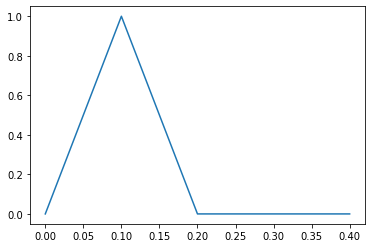

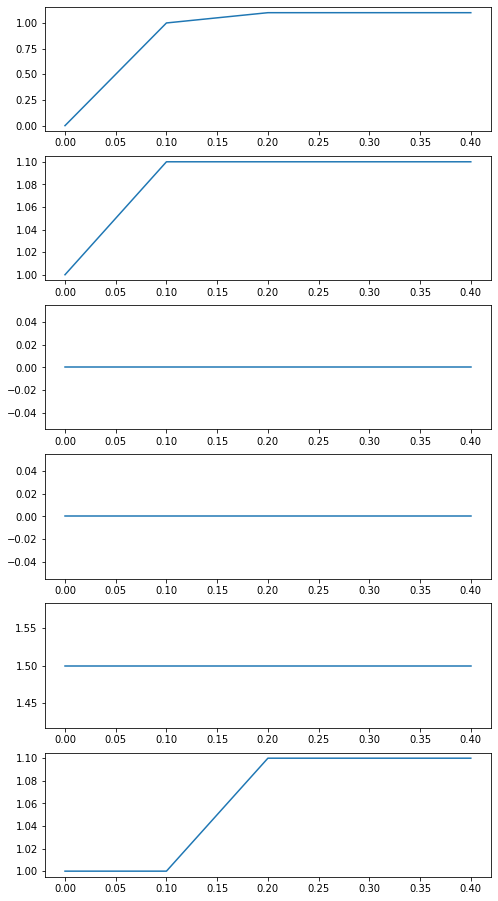

In [508]:
dur = 0.4

a.params.duration = dur

target = a.getZeroTarget()
control1 = a.getZeroControl()
a.params.ext_exc_current = 0.

a.run(control=control1)

control1[0,0,1] += 1.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)
plt.plot(a.t, control1[0,0,:])

target[:,0,:] = a.rates_exc[:,:]

fig, axes = plt.subplots(6, figsize=(8, 16))
axes[0].plot(a.t, a.state["rates_exc"][0,:])
axes[1].plot(a.t, a.state["mufe"][0,:])
axes[2].plot(a.t, a.state["seem"][0,:])
axes[3].plot(a.t, a.state["seev"][0,:])
axes[4].plot(a.t, a.state["sigmae_f"][0,:])
axes[5].plot(a.t, a.state["tau_exc"][0,:])

In [511]:
max_cntrl = 10. * 5.
start_step = 11
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init, a.params.seem_init, a.params.seev_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
control2 += 1.

max_it = 100

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#0.7262797905237487

set cost params
RUN  0 , total integrated cost =  0.5019423486176855
grad  =  [[[2.         2.02513349 2.02416251 2.01468446 2.        ]]]
step =  0.4946666442844543
RUN  1 , total integrated cost =  0.0015288630281386812
grad  =  [[[ 0.02133342 -0.03357792 -0.02260189 -0.00319393  0.02133342]]]
step =  0.4928811794512169
RUN  2 , total integrated cost =  0.0014659029629247007
grad  =  [[[0.00030374 0.00026737 0.00027959 0.00027378 0.00030374]]]
step =  0.4987722621509764
RUN  3 , total integrated cost =  0.0014658926127757749
grad  =  [[[ 7.45820340e-07 -7.61809262e-06 -6.37256758e-06 -3.66653356e-06
    7.45820340e-07]]]
step =  3.407039015183118e-06
RUN  4 , total integrated cost =  0.0014658926127757747
grad  =  [[[ 7.45815258e-07 -7.61803935e-06 -6.37252304e-06 -3.66650793e-06
    7.45815258e-07]]]
step =  2.3051742430912386e-07
RUN  5 , total integrated cost =  0.0014658926127757738
grad  =  [[[ 7.45814914e-07 -7.61803575e-06 -6.37252002e-06 -3.66650620e-06
    7.45814914e-07]]]


[[[3.72907457e-07 1.46505797e-02 9.71491970e-03 4.84047508e-03
   3.72907457e-07]]]


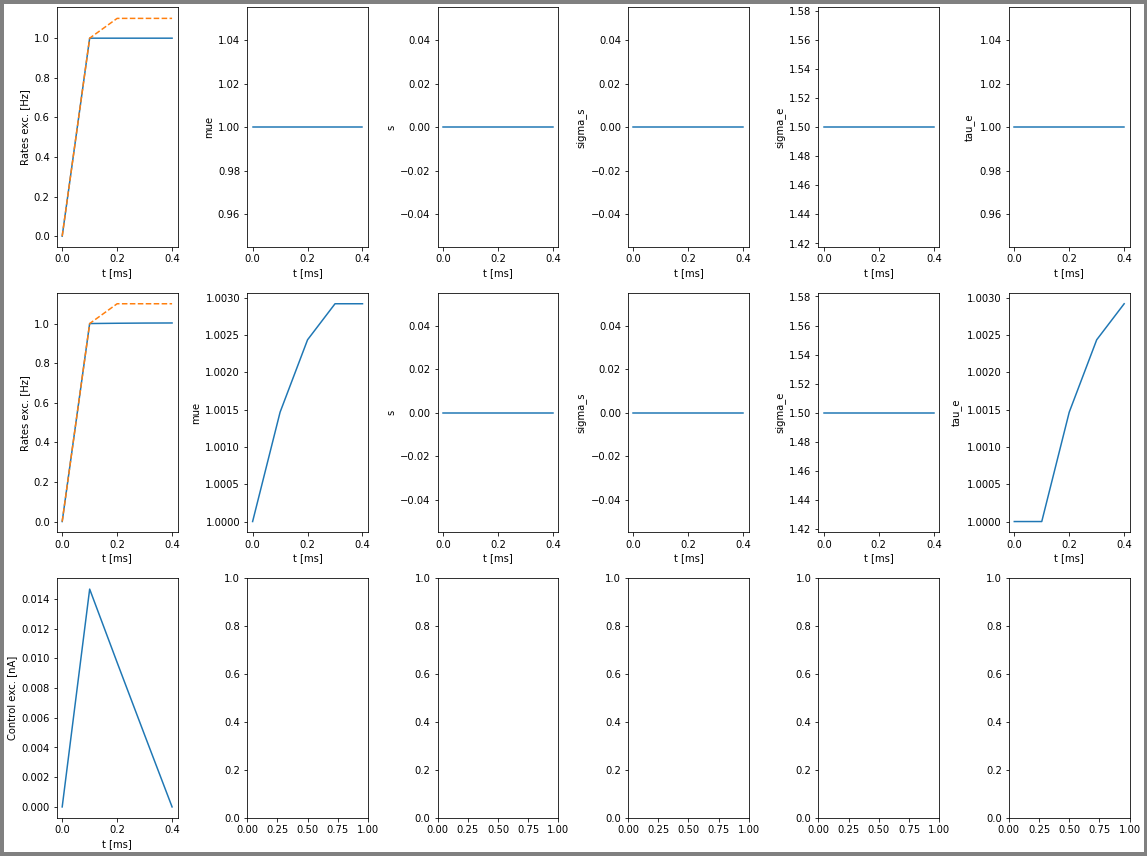

In [512]:
#0.05449064953697066
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [513]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 40

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

D:\Promotion\neurolib\neurolib\models\e\timeIntegration.py:132: RuntimeWarning: divide by zero encountered in double_scalars
  mufe_rhs = (control_ext[no,0,i] + ext_exc_current[no,i-startind+1]) / tau_exc[no,i]# - mufe[no,i-1]) / tau_exc[no,i] #+ ext_exc_current[no,i-startind+1] - mufe[no,i-1]) / tau_exc[no,i]#  )
ERROR:root:explosion in model output!


start ind =  1
RUN  0 , total integrated cost:  0.30194234861771324
RUN  1 , total integrated cost:  0.001487293744994596
RUN  2 , total integrated cost:  0.0014658928712399184
change helped, counter =  2
RUN  3 , total integrated cost:  0.0014658926113167658
change helped, counter =  3
RUN  4 , total integrated cost:  0.0014658926113167653
Control only changes marginally.
RUN  5 , total integrated cost:  0.0014658926113167653
Improved over  5  iterations by  100  percent.


[[[3.72907457e-07 1.46473377e-02 9.71578833e-03 4.84231436e-03
   3.72907457e-07]]]


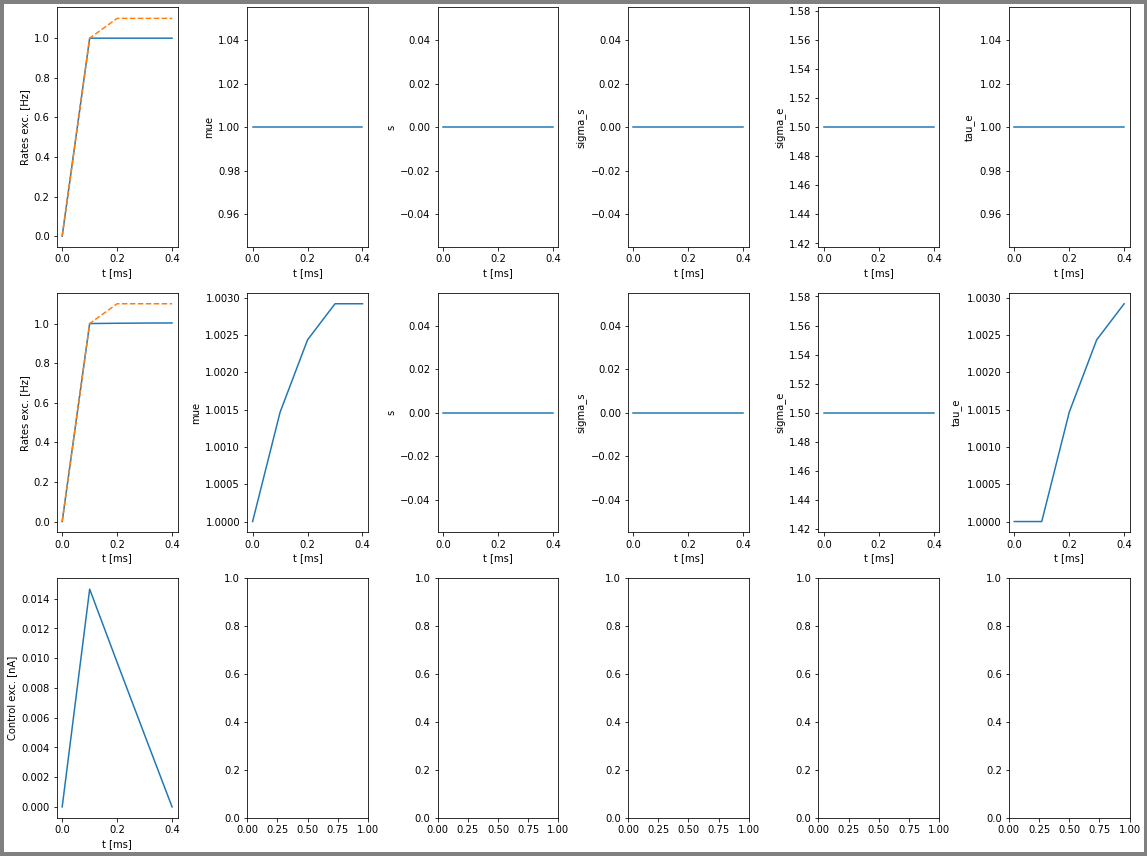

In [514]:
# 0.008474847806487532
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

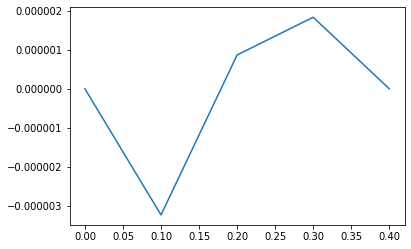

In [515]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

In [274]:
def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

In [323]:
gradient_r = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        res1 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1

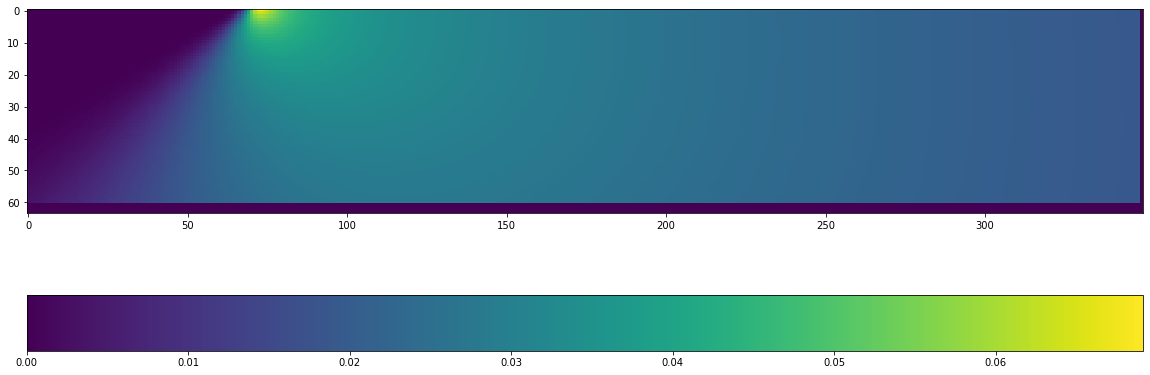

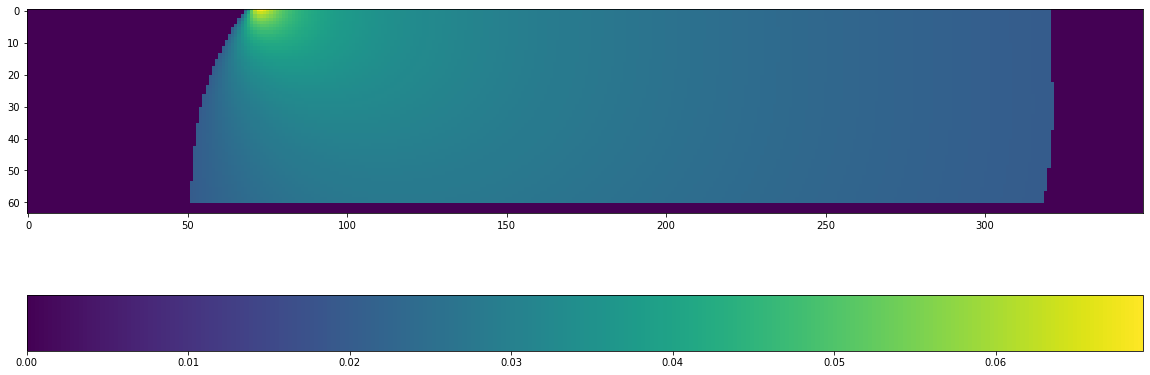

In [307]:
# gradient wrt mu

plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

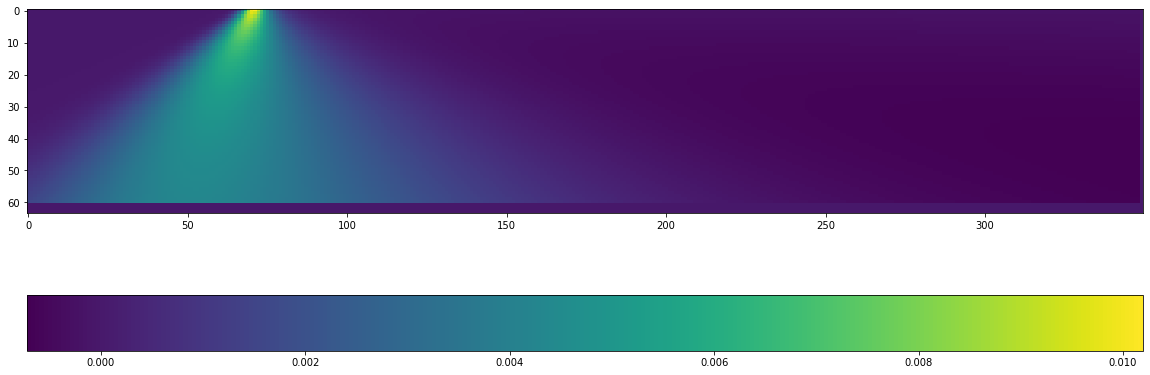

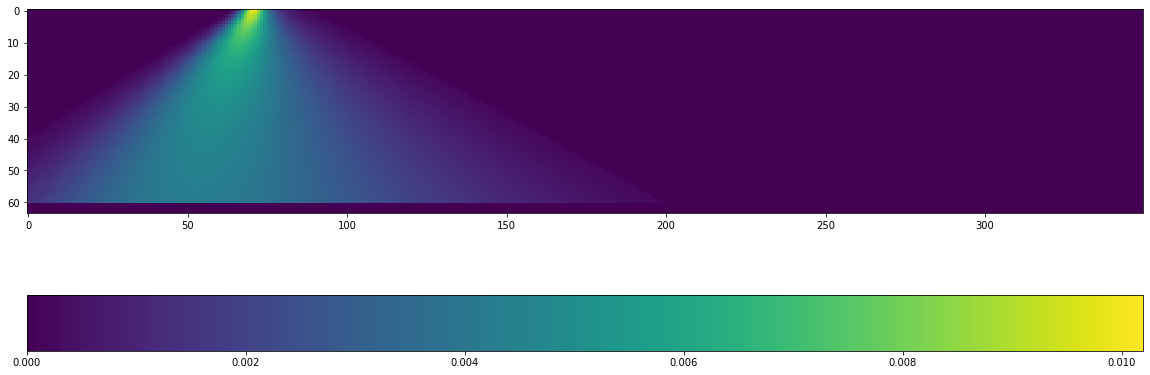

In [270]:
# gradient wrt sigma

plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,1].T)
plt.colorbar(orientation="horizontal")
plt.show()

threshold = 0.0002
large_g_sigma = gradient_r.copy()
large_g_sigma[large_g_sigma < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g_sigma[:,:,1].T)
plt.colorbar(orientation="horizontal")
plt.show()

In [122]:
gradient_tau = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        res1 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        gradient_tau[mu, sigma, 0] = res0
        gradient_tau[mu, sigma, 1] = res1

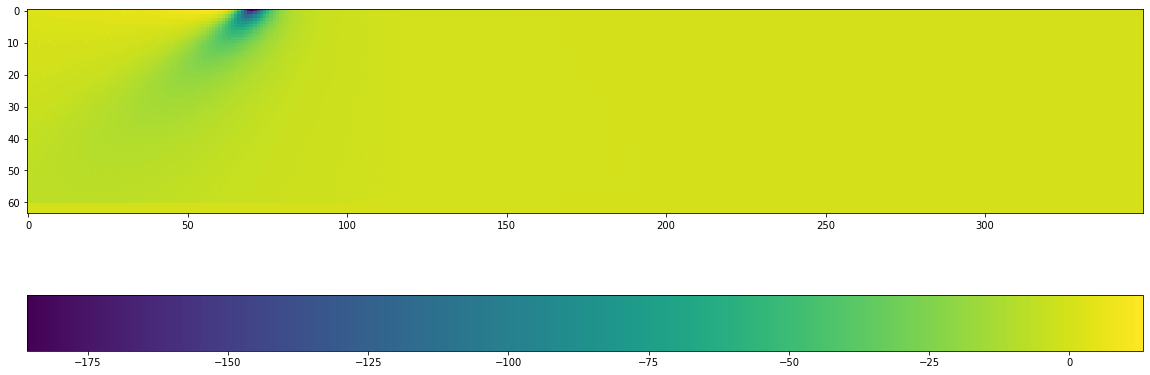

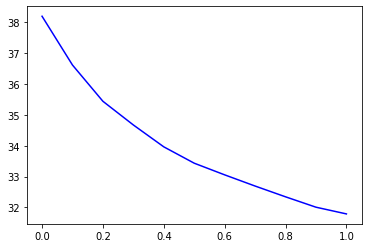

[38.19982642 36.61728213 35.44143969 34.67350651 33.96380788 33.43360313
 33.05546137 32.69242294 32.34315578 32.00645761 31.78843922]
[-4.3625  -2.6175  -1.745   -1.30875 -1.30875 -0.8725  -0.8725  -0.8725
 -0.8725  -0.43625 -0.43625]


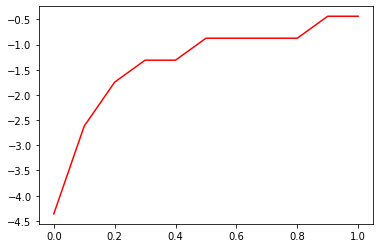

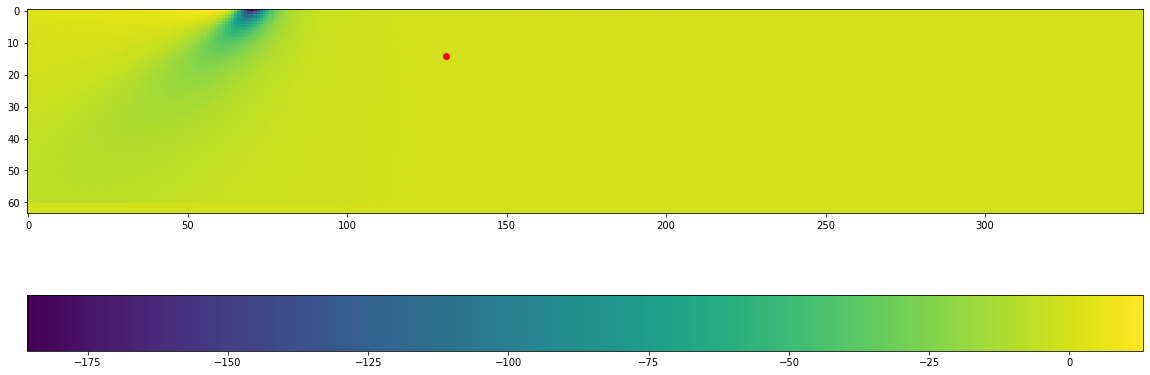

In [325]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_tau[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

grad_r = np.zeros(( len(a.state["mufe"][0,:]) ))
grad_tau = np.zeros(( len(a.state["mufe"][0,:]) ))
for m in range(len(a.state["mufe"][0,:])):
    index_ = getindex(a.params.Irange[0], a.params.Irange[-1], len(a.params.Irange), a.state["mufe"][0,m])
    index_sigma_ = getindex(a.params.sigmarange[0], a.params.sigmarange[-1], len(a.params.sigmarange), 1.5)
    grad_r[m] = gradient_r[index_, index_sigma_, 0]
    grad_tau[m] = gradient_tau[index_, index_sigma_, 0]
    
plt.plot(a.t, grad_r*1e3, c="blue")
plt.show()
print(grad_r*1e3)
print(grad_tau)
plt.plot(a.t, grad_tau, c="red")
plt.show()


threshold = 0.02
large_g = gradient_tau.copy()
large_g[np.abs(large_g) < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.plot(index_, index_sigma_, "o", c="red")
plt.colorbar(orientation="horizontal")
plt.show()

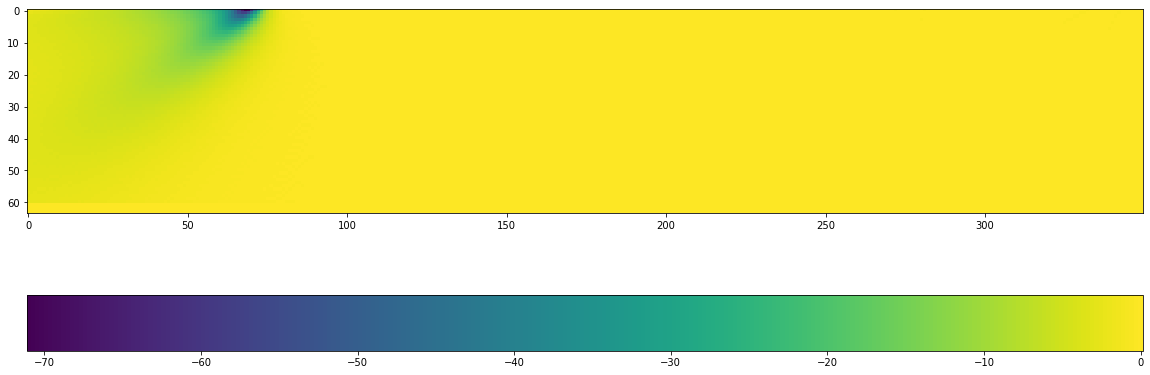

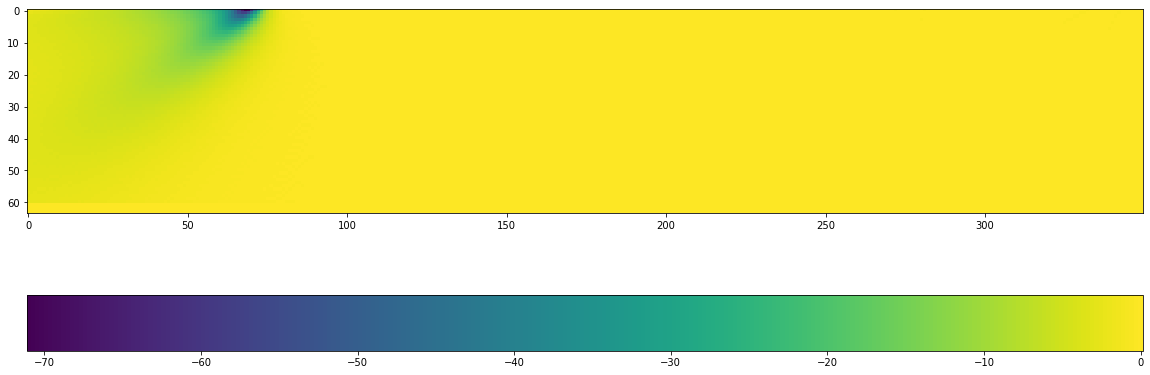

In [272]:
# gradient wrt sigma

plt.figure(figsize=(20,10))
plt.imshow(gradient_tau[:,:,1].T)
plt.colorbar(orientation="horizontal")
plt.show()

threshold = 0.0002
large_g_sigma = gradient_tau.copy()
large_g_sigma[np.abs(large_g_sigma) < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g_sigma[:,:,1].T)
plt.colorbar(orientation="horizontal")
plt.show()